In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt


In [46]:
# Import the Predict Students' Dropout and Academic Success dataset from GitHub
# Using the raw GitHub URL without token for better reliability
url = 'https://raw.githubusercontent.com/pratyushniraula/studentDataset/main/data.csv'
df = pd.read_csv(url, sep=';')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [48]:
# Encode categorical columns
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

/Users/pratyushniraula/Documents/Work/Classes/CS_4372/classpackages/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/pratyushniraula/Documents/Work/Classes/CS_4372/classpackages/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


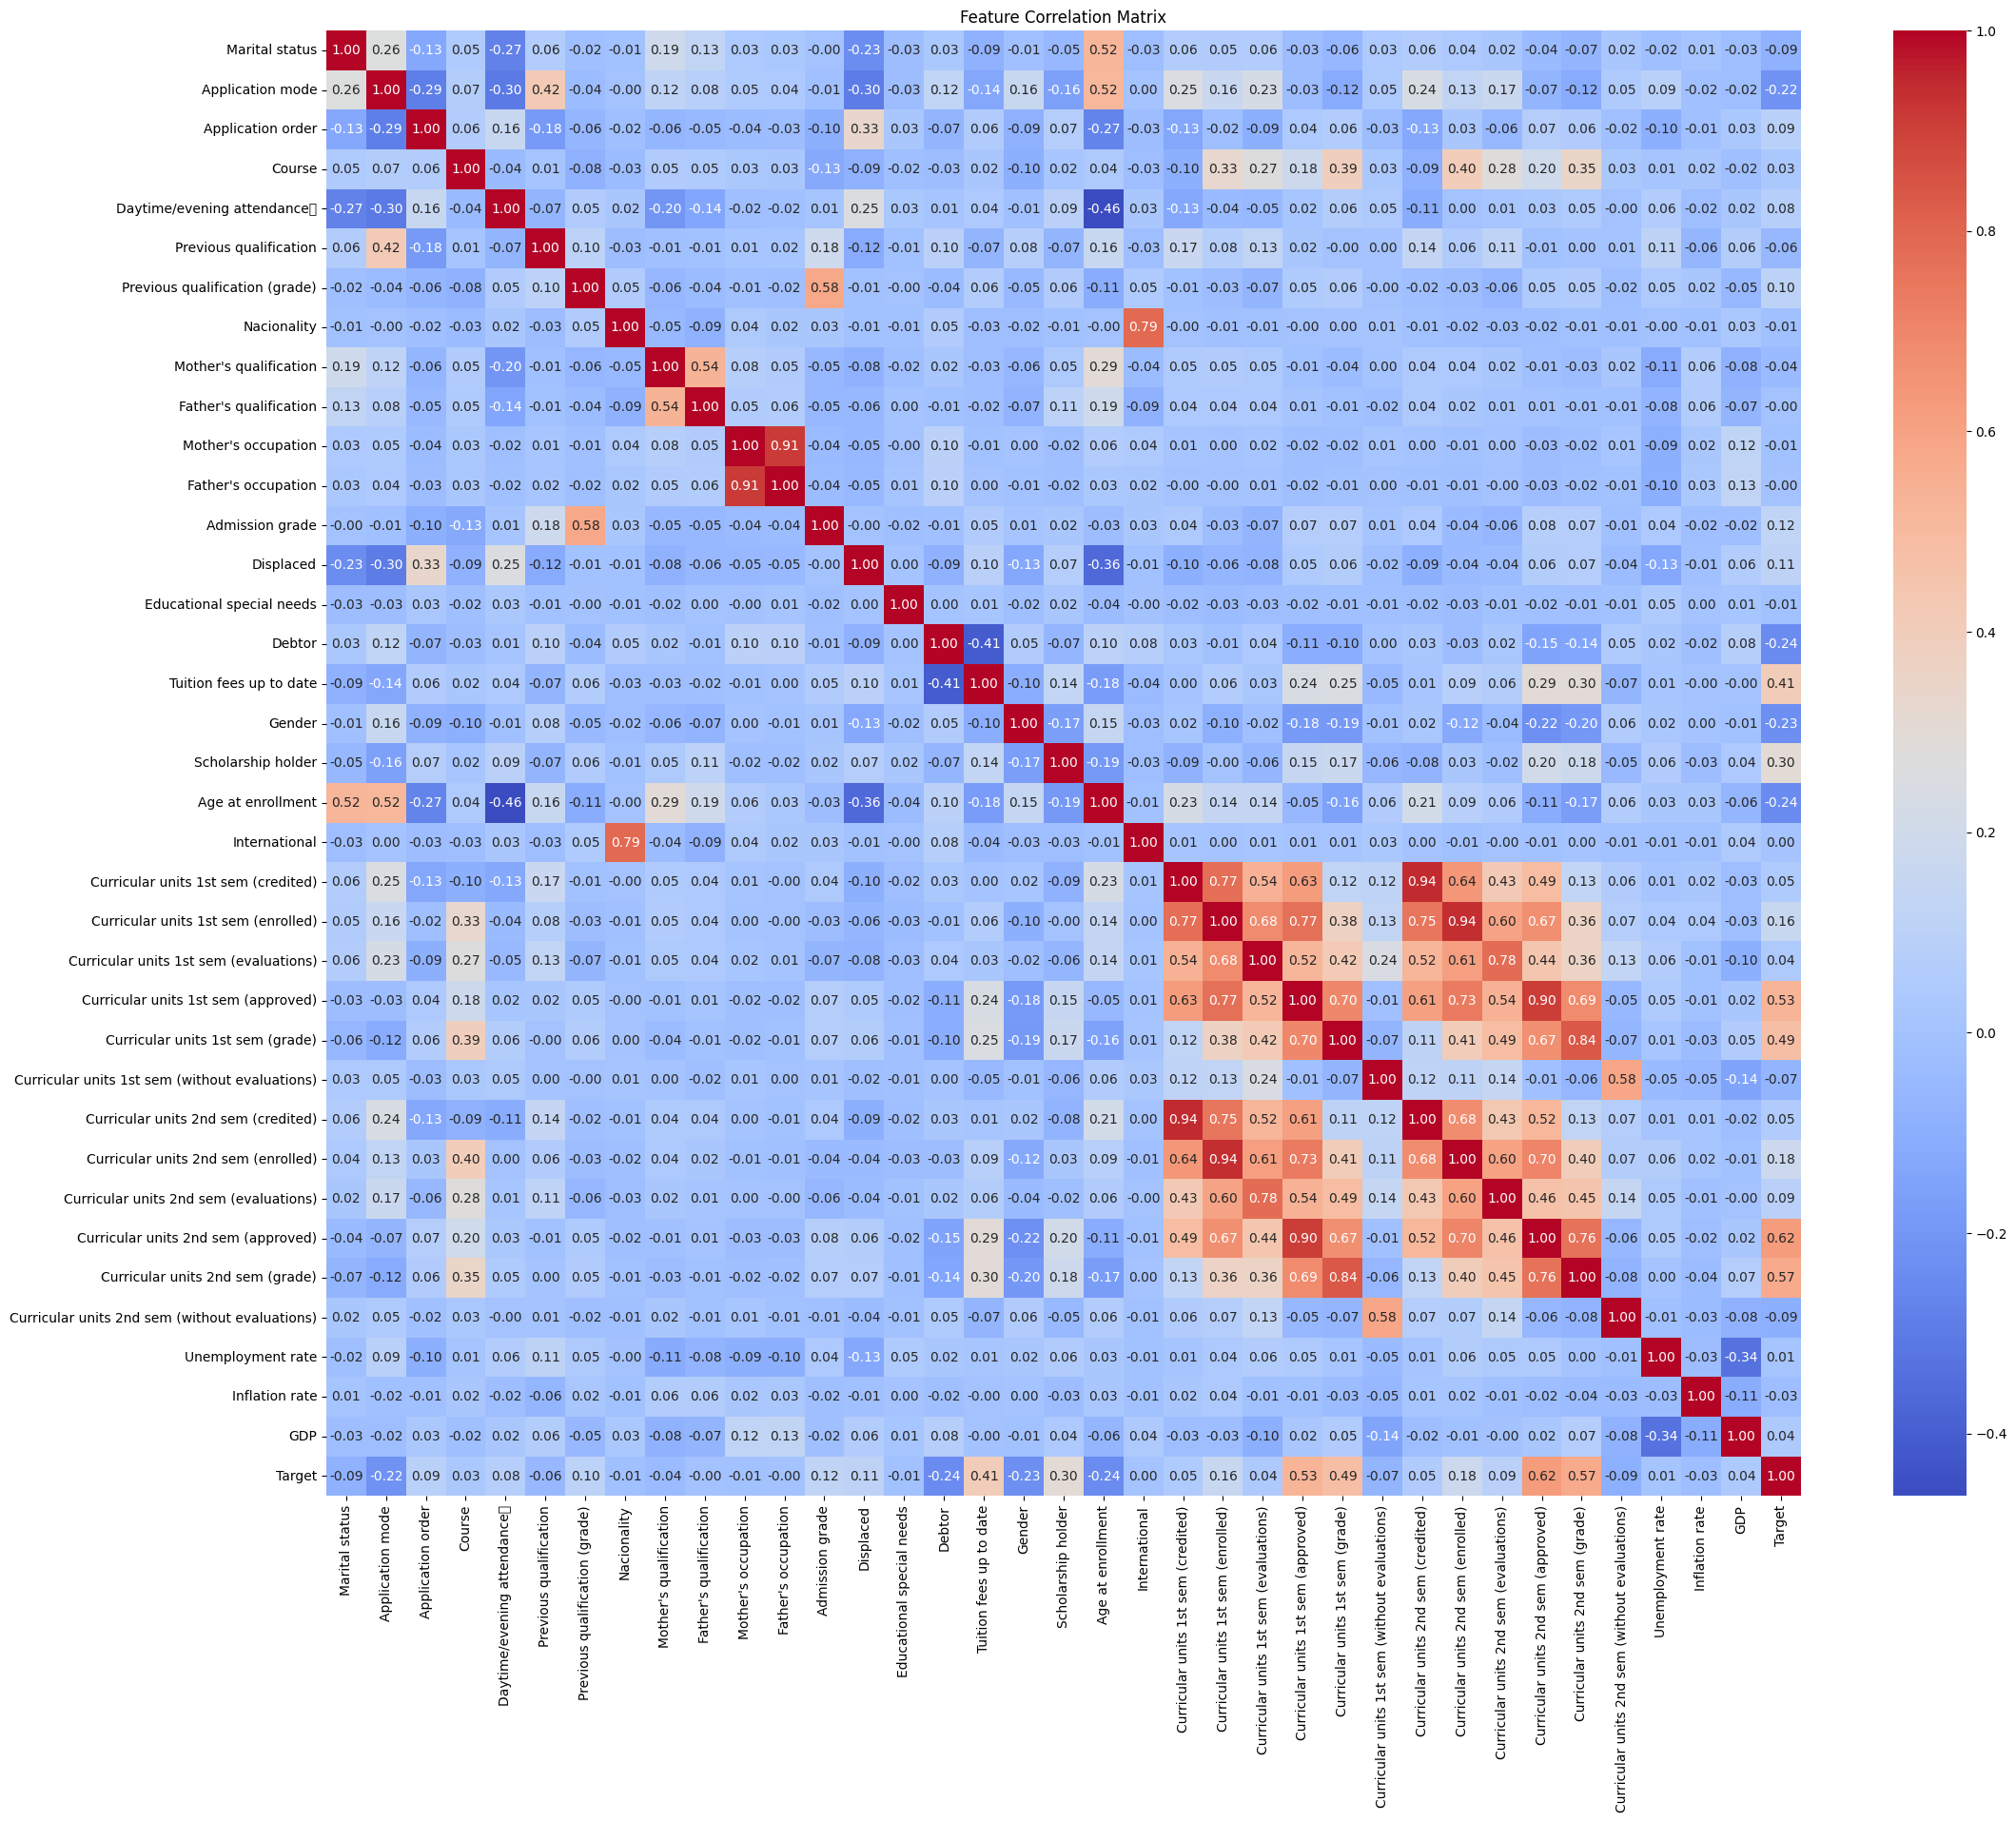

In [49]:
#heatmap
plt.figure(figsize=(25, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [50]:
# Drop irrelevant columns since they don't contribute to prediction
df = df.drop(columns=['Marital status', 'Application mode', 'Application order'], errors='ignore')

# Handle missing values (if any)
df = df.fillna(df.median())

# Split features/target
X = df.drop('Target', axis=1)
y = df['Target']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=6, min_samples_split=60)
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,60
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Decision Tree Accuracy: 0.7468926553672316
Decision Tree Train Accuracy: 0.7804464538005086
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.69      0.74       284
           1       0.51      0.42      0.46       159
           2       0.78      0.90      0.84       442

    accuracy                           0.75       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885

Decision Tree Confusion Matrix:
 [[195  40  49]
 [ 29  66  64]
 [ 18  24 400]]


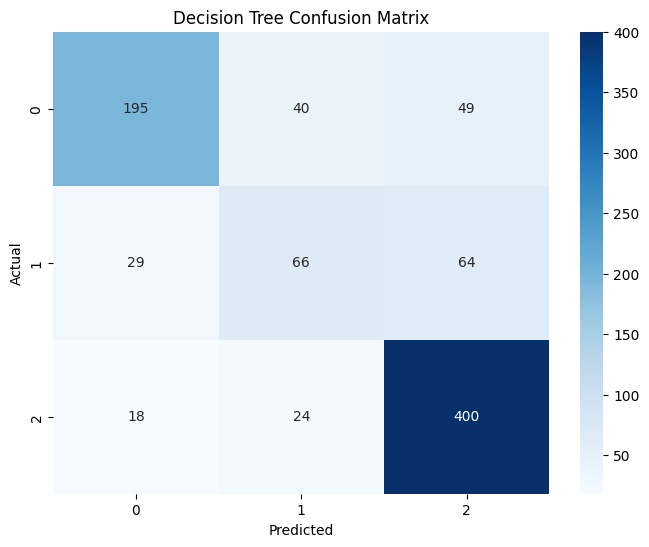

In [94]:
#test the decision tree model, output what the tree looks like and the accuracy score, classification report, and confusion matrix
y_pred_dt = dt.predict(X_test)
y_train_pred_dt = dt.predict(X_train)
#test accuracy score
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Train Accuracy:", accuracy_score(y_train, y_train_pred_dt))
#print classification report
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
#print confusion matrix
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
#visual confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

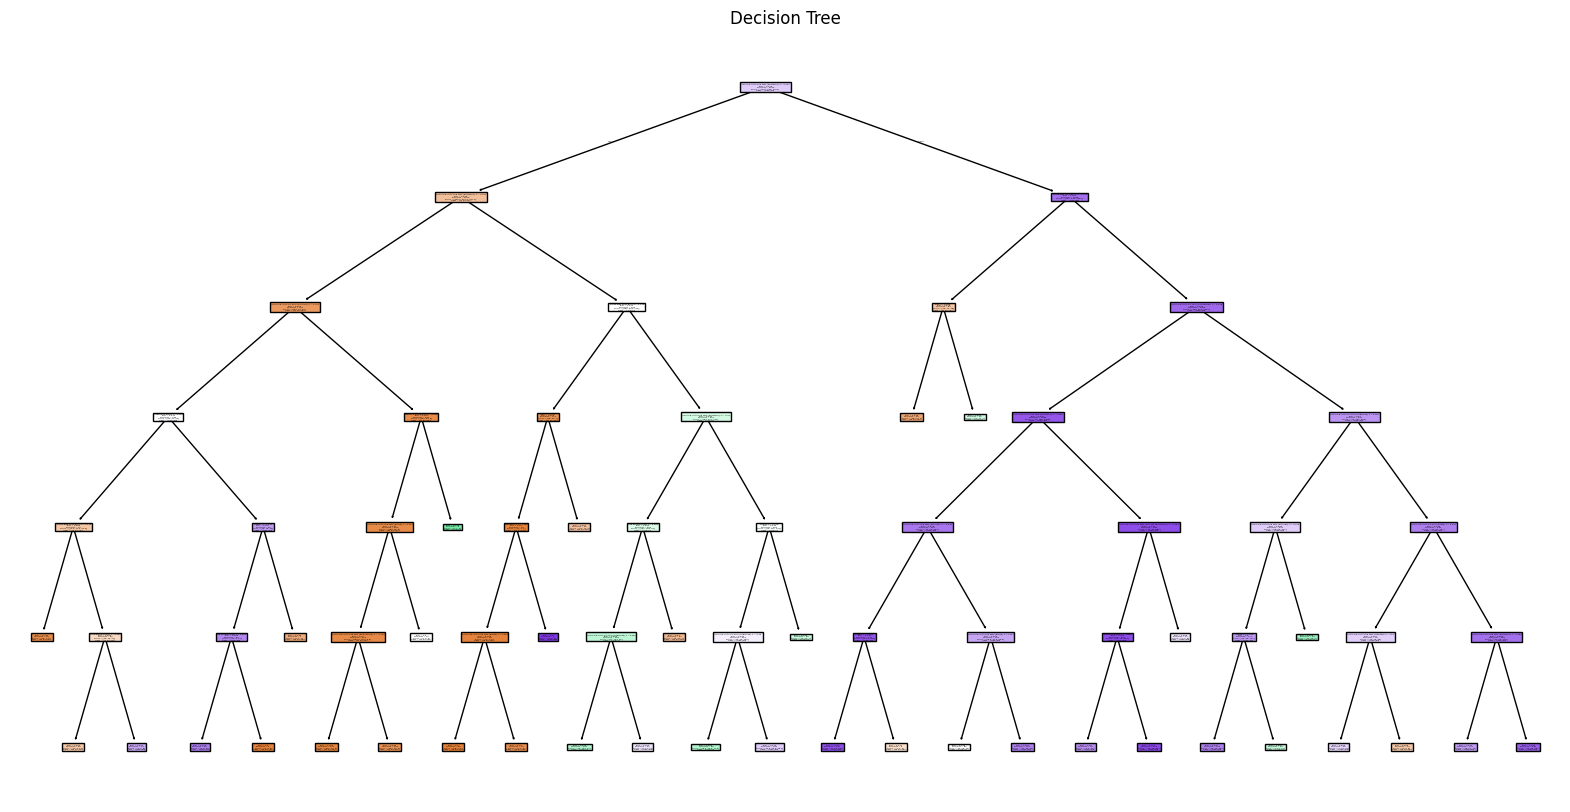

In [76]:
#show what the tree looks like
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['No Dropout', 'Enrolled', 'Graduate'])
plt.title('Decision Tree')
plt.show()

In [77]:
#get the feature importance of the decision tree
feature_importance = dt.feature_importances_
# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Feature Importance:\n", importance_df)

Feature Importance:
                                            Feature  Importance
27             Curricular units 2nd sem (approved)    0.685774
13                         Tuition fees up to date    0.091472
19             Curricular units 1st sem (enrolled)    0.048902
20          Curricular units 1st sem (evaluations)    0.031069
25             Curricular units 2nd sem (enrolled)    0.027233
21             Curricular units 1st sem (approved)    0.021512
32                                             GDP    0.013132
0                                           Course    0.012842
16                               Age at enrollment    0.011303
9                                  Admission grade    0.010773
28                Curricular units 2nd sem (grade)    0.009839
7                              Mother's occupation    0.008293
22                Curricular units 1st sem (grade)    0.007306
12                                          Debtor    0.006328
24             Curricular units 2n

In [183]:
# AdaBoost
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42, learning_rate=0.5)
ada.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,100
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


AdaBoost Accuracy: 0.7536723163841808
AdaBoost Train Accuracy: 0.7541678440237355
AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       284
           1       0.54      0.24      0.33       159
           2       0.79      0.92      0.85       442

    accuracy                           0.75       885
   macro avg       0.69      0.65      0.65       885
weighted avg       0.73      0.75      0.73       885

AdaBoost Confusion Matrix:
 [[224  16  44]
 [ 58  38  63]
 [ 20  17 405]]


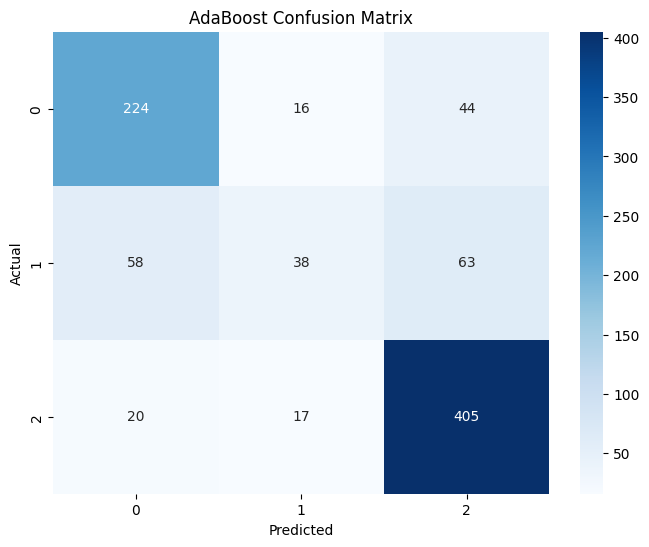

In [184]:
#predict and evaluate AdaBoost
y_pred_ada = ada.predict(X_test)
y_train_pred_ada = ada.predict(X_train)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Train Accuracy:", accuracy_score(y_train, y_train_pred_ada))
print("AdaBoost Classification Report:\n", classification_report(y_test, y_pred_ada))

#confusion matrix for true positive true negatives and false positives and false negatives
print("AdaBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
#visual con`fusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Blues')
plt.title('AdaBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [193]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=12, min_samples_split=50)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,50
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest Accuracy: 0.7762711864406779
Random Forest Train Accuracy: 0.8180276914382594
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79       284
           1       0.65      0.31      0.42       159
           2       0.78      0.94      0.85       442

    accuracy                           0.78       885
   macro avg       0.75      0.68      0.69       885
weighted avg       0.76      0.78      0.76       885

Random Forest Confusion Matrix:
 [[221  12  51]
 [ 42  49  68]
 [ 11  14 417]]


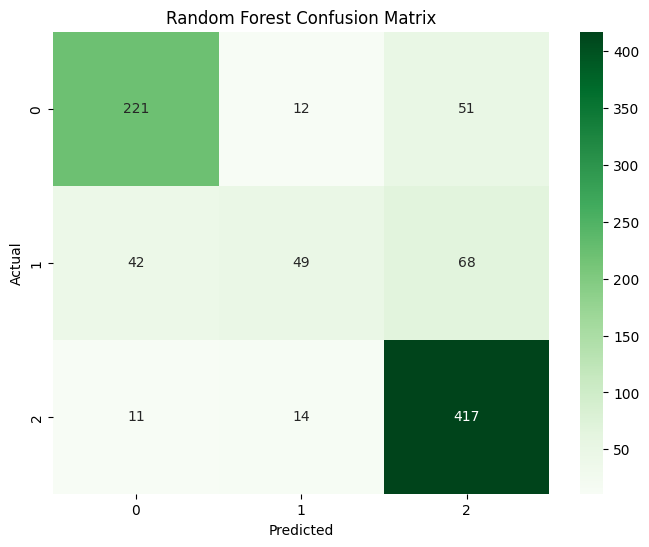

In [194]:
#analyze and evaluate Random Forest
y_pred_rf = rf.predict(X_test)
y_train_pred_rf = rf.predict(X_train)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
#visual confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [209]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=200, max_depth=6, learning_rate=0.1)
xgb.fit(X_train, y_train)

/Users/pratyushniraula/Documents/Work/Classes/CS_4372/classpackages/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [00:53:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


XGBoost Accuracy: 0.7717514124293785
XGBoost Train Accuracy: 0.98982763492512
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       284
           1       0.55      0.45      0.49       159
           2       0.82      0.91      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885

XGBoost Confusion Matrix:
 [[209  33  42]
 [ 38  72  49]
 [ 13  27 402]]


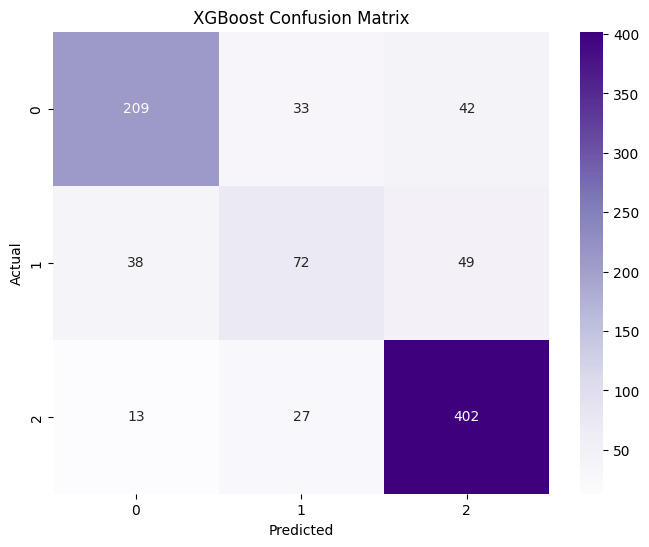

In [210]:
#analyze and evaluate xgboost
y_pred_xgb = xgb.predict(X_test)
y_train_pred_xgb = xgb.predict(X_train)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
#visual confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [211]:
#gather all of the confusion matrices and print
    #decision tree
print("decision tree confusion matrix")
print(confusion_matrix(y_test, y_pred_dt))
print("ada boost confusion matrix")
print(confusion_matrix(y_test, y_pred_ada))
print("random forest confusion matrix")
print(confusion_matrix(y_test, y_pred_rf))
print("xg boost confusion matrix")
print(confusion_matrix(y_test, y_pred_xgb))



decision tree confusion matrix
[[195  40  49]
 [ 29  66  64]
 [ 18  24 400]]
ada boost confusion matrix
[[224  16  44]
 [ 58  38  63]
 [ 20  17 405]]
random forest confusion matrix
[[221  12  51]
 [ 42  49  68]
 [ 11  14 417]]
xg boost confusion matrix
[[209  33  42]
 [ 38  72  49]
 [ 13  27 402]]


Decision Tree:
    class 0 (dropout):
        TP:195
        FP:47
        FN:89
        TN:554
    class 1 (enrolled):
        TP:66
        FP:64
        FN:93
        TN:662
    class 2 (graduate):
        TP:
        FP:
        FN:
        TN:
Adaboost:
Random Forest:
xgboost: